Compute mean connectivity from HCP7T dataset

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [14]:
lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         'atlas-custom_subcort-tians3_cort-carpet',
                         'atlas-custom_subcort-tians3_cort-carpet_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [3]:
region_list = ['PUT-VA-lh',
 'PUT-DA-lh',
 'PUT-VP-lh',
 'PUT-DP-lh',
 'CAU-VA-lh',
 'CAU-DA-lh',
 'pCAU-lh',
 'PUT-VA-rh',
 'PUT-DA-rh',
 'PUT-VP-rh',
 'PUT-DP-rh',
 'CAU-VA-rh',
 'CAU-DA-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp']

In [4]:
region_list

['PUT-VA-lh',
 'PUT-DA-lh',
 'PUT-VP-lh',
 'PUT-DP-lh',
 'CAU-VA-lh',
 'CAU-DA-lh',
 'pCAU-lh',
 'PUT-VA-rh',
 'PUT-DA-rh',
 'PUT-VP-rh',
 'PUT-DP-rh',
 'CAU-VA-rh',
 'CAU-DA-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp']

In [4]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')

## Read in participant connectivity matrices

In [5]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tians3_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))

In [18]:
print(conn_files)

['/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/100610/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tians3_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/102311/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tians3_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/102816/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tians3_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/104416/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tians3_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv', '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/105923/connecto

In [6]:
print(len(conn_files))

100


In [7]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


             0            1            2            3            4   \
0   3860.860893  2255.435563   499.597474    18.188766   530.309088   
1   2255.435563  2170.985591   892.808425  1744.173615    14.790018   
2    499.597474   892.808425  1324.041865   605.882095    14.589335   
3     18.188766  1744.173615   605.882095  1743.920533     0.000000   
4    530.309088    14.790018    14.589335     0.000000  1584.676687   
5    420.541497  1192.021696   114.390596   174.212943  4082.607249   
6     21.585875   807.142970   109.800144  1016.695622   358.712312   
7     33.942493    13.376352    38.762449     0.000000    17.562279   
8      9.292955    23.725615    19.940405     8.472162     7.323464   
9     17.065034    31.899341    98.722855    16.445323     1.385063   
10     0.287141    56.109286     8.456884    65.554573     0.678034   
11     7.235478     0.594683     3.744791     0.266873    12.689611   
12     5.294243    11.605751     2.476211     3.571007     2.079493   
13    

In [8]:
# loop through each subject's connectivity matrix and clean up the formatting
num_regions = len(test_df) # number of regions of interest in the HCP analysis
num_subjects = len(conn_files)
connmats = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []
for sx, matrix_fpath in enumerate(conn_files):

    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    
    connmats[sx,:,:] = sub_df.to_numpy()
    
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0) # sub_df.iloc[:,0]

In [9]:
np.shape(connmats)

(100, 24, 24)

In [10]:
# check the streamline count matrix (region x subject)
slcounts

array([[ 8631.29392627,  5523.38818358,  7036.72913972, ...,
         3789.55338588,  3634.97988841,  6551.33640099],
       [ 9805.02082975,  5161.86478095,  6537.11843434, ...,
         4340.19317251,  4857.85015437,  4252.64530816],
       [11826.90823728, 11537.77035391, 14674.24452339, ...,
        10272.27009378, 11164.4060273 , 18000.23163895],
       ...,
       [53652.38690144, 51595.26494971, 62103.47678675, ...,
        41626.68092059, 45294.24164437, 38247.49656543],
       [21766.36793911, 13567.40311891, 19380.58447327, ...,
        25477.59347066,  9238.49164583, 17201.52354977],
       [56647.28237627, 50954.11980428, 63311.55079417, ...,
        54103.9955786 , 50458.34097642, 36842.36158867]])

## Compute mean streamline count per ROI

In [11]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 5188.61409372  5264.39992549 10116.42833909  5438.3899538
  3496.80047986  5316.44917203  4803.67603114  7417.48202977
  6695.89308392 10421.03562521  6643.54590335  3523.42330657
  5671.97058714  6377.81020724 28013.80308517 31410.28737724
 47712.19511167 26481.42788169 38633.05719553 26688.32042955
 26141.96766473 41723.78065983 15683.77258772 46461.44642816]
(24,)


In [12]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[2.21414473e+03 1.04794639e+03 4.17962027e+02 3.33164177e+01
  5.43597975e+02 3.01392560e+02 1.93814816e+01 8.12746715e+00
  1.98376778e+00 3.28530572e+00 1.48648854e-01 6.13028304e+00
  2.93451251e+00 7.07442122e-01 9.23419785e+00 5.30481880e+02
  2.72507837e+01 1.01135933e+01 8.25665484e+00 4.34837051e-02
  2.08804205e+00 2.13436586e-02 3.30015305e-02 3.21035655e-02]
 [1.04794639e+03 1.00159478e+03 6.02391580e+02 1.09195086e+03
  9.06385787e+00 4.52422187e+02 2.88764292e+02 2.91926460e+00
  7.73293001e+00 3.89720261e+00 1.09467213e+01 1.00973120e+00
  1.44739067e+01 1.71153272e+01 8.02037775e+01 4.36703785e+02
  1.48238428e+02 1.50421262e+01 3.06990418e+01 2.58422588e-02
  1.19189911e+00 3.49248278e-02 7.90586367e-03 2.31629385e-02]
 [4.17962027e+02 6.02391580e+02 1.10034405e+03 8.05756131e+02
  4.46189216e+00 9.25198911e+01 1.84884461e+02 8.13841818e+00
  3.34524816e+00 2.28234951e+01 5.89815258e+00 1.73694683e+00
  3.31982389e+00 7.74465938e+00 2.61445782e+03 2.91010001e+03
  1.04

In [16]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [17]:
mean_df

,mean_slcount,seed,PUT-VA-lh,PUT-DA-lh,PUT-VP-lh,PUT-DP-lh,CAU-VA-lh,CAU-DA-lh,pCAU-lh,PUT-VA-rh,...,L-HG,L-PP,L-PT,L-STGa,L-STGp,R-HG,R-PP,R-PT,R-STGa,R-STGp
0,5188.614094,PUT-VA-lh,2214.144728,1047.946393,417.962027,33.316418,543.597975,301.392560,19.381482,8.127467,...,9.234198,530.481880,27.250784,10.113593,8.256655,0.043484,2.088042,0.021344,0.033002,0.032104
1,5264.399925,PUT-DA-lh,1047.946393,1001.594776,602.391580,1091.950865,9.063858,452.422187,288.764292,2.919265,...,80.203777,436.703785,148.238428,15.042126,30.699042,0.025842,1.191899,0.034925,0.007906,0.023163
2,10116.428339,PUT-VP-lh,417.962027,602.391580,1100.344050,805.756131,4.461892,92.519891,184.884461,8.138418,...,2614.457821,2910.100010,1041.795568,181.412698,87.593987,3.349422,4.920844,10.758470,0.086792,0.625949
3,5438.389954,PUT-DP-lh,33.316418,1091.950865,805.756131,1302.925137,0.564204,63.748378,550.572744,0.059222,...,298.118901,1019.963857,160.172666,32.771076,35.496395,0.011784,2.244307,0.027591,0.000000,0.000000
4,3496.800480,CAU-VA-lh,543.597975,9.063858,4.461892,0.564204,1052.104105,1585.685667,263.582161,3.981515,...,0.278303,1.952361,0.952266,0.038954,0.158246,0.036876,1.116567,0.203480,0.005081,0.028724
5,5316.449172,CAU-DA-lh,301.392560,452.422187,92.519891,63.748378,1585.685667,1560.973723,1086.939196,1.864049,...,4.992315,44.070434,14.576166,2.698748,2.112593,0.159002,0.989582,0.431399,0.008198,0.012849
6,4803.676031,pCAU-lh,19.381482,288.764292,184.884461,550.572744,263.582161,1086.939196,2130.178740,0.499550,...,6.814211,80.240833,21.147245,2.878418,5.957895,0.993423,4.810105,5.989047,0.036933,0.080762
7,7417.482030,PUT-VA-rh,8.127467,2.919265,8.138418,0.059222,3.981515,1.864049,0.499550,2873.034807,...,0.021047,2.668628,0.052190,0.065473,0.004356,17.434982,1570.977675,44.567385,15.563110,28.073672
8,6695.893084,PUT-DA-rh,1.983768,7.732930,3.345248,4.145315,0.695384,14.481784,16.413947,1487.051048,...,0.012065,0.688049,0.031034,0.068051,0.002300,169.327094,484.592446,428.627442,13.213966,154.521056
9,10421.035625,PUT-VP-rh,3.285306,3.897203,22.823495,4.246108,0.907927,2.772471,7.827870,565.900435,...,3.008329,3.756558,6.292822,0.079476,0.038892,2630.043552,2137.709593,1453.031755,141.391692,393.810202


In [ ]:
# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_Oct')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity.txt')
#os.makedirs(out_dir, exist_ok=True)
#mean_df.to_csv(out_fpath, sep='\t', index=False)

In [33]:
out_dir

'/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/group_plots_Oct'

### Plot distributions

In [30]:
import seaborn as sns

In [31]:
connmats.shape

(100, 24, 24)

<Axes: >

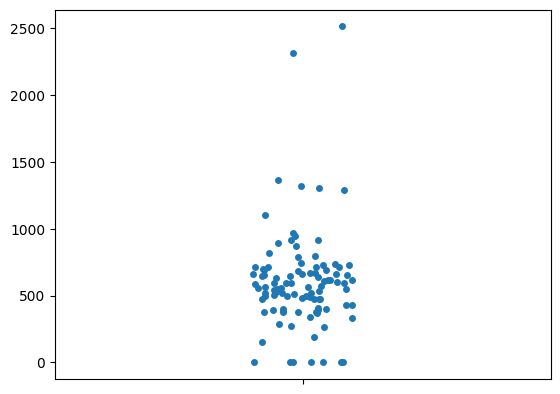

In [32]:
sns.stripplot(connmats[:,1,2])

## Combine separate participants into single dataframe

**TO DO**

Step 1: create pd DataFrame for each participant

Step 2: keep rows = striatum, columns = cortex; drop cortex rows, striatum columns

Step 3: add Rostral/Caudal column, aligned with striatum ROI

Step 4: merge all participants' dataframes

Step 5: run ANOVA with Rostral/Caudal as feature

In [20]:
len(connmats)

100

In [22]:
connmats.shape

(100, 24, 24)

In [17]:
m,n,r = connmats.shape

out_arr = np.column_stack((np.repeat(np.arange(m),n),connmats.reshape(m*n,-1)))
out_df = pd.DataFrame(out_arr)

In [18]:
out_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.0,3860.860893,2255.435563,499.597474,18.188766,530.309088,420.541497,21.585875,33.942493,9.292955,...,10.443239,842.356105,52.160599,7.048911,29.755533,0.508072,8.645413,0.526177,0.000000,0.000000
1,0.0,2255.435563,2170.985591,892.808425,1744.173615,14.790018,1192.021696,807.142970,13.376352,23.725615,...,55.391193,196.698866,232.873314,10.624555,56.239681,0.000000,10.918109,0.551111,0.000000,0.000000
2,0.0,499.597474,892.808425,1324.041865,605.882095,14.589335,114.390596,109.800144,38.762449,19.940405,...,2866.256197,3838.259675,935.537449,280.590499,118.869289,3.535871,36.283277,10.859709,0.000000,0.583558
3,0.0,18.188766,1744.173615,605.882095,1743.920533,0.000000,174.212943,1016.695622,0.000000,8.472162,...,237.990263,951.603146,226.308200,22.422109,49.552761,0.000000,1.987225,0.000000,0.000000,0.000000
4,0.0,530.309088,14.790018,14.589335,0.000000,1584.676687,4082.607249,358.712312,17.562279,7.323464,...,0.485812,2.938104,6.195766,0.000000,0.790048,0.471375,0.745360,2.122929,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,99.0,0.000000,0.000000,0.614249,0.000000,0.000000,0.000000,0.000000,24.272713,259.580766,...,0.000000,0.771965,0.000000,0.000000,0.000000,8112.917863,7822.501101,8007.613125,2374.087039,1352.537845
2396,99.0,11.868657,0.510766,10.641932,0.000000,0.950192,0.459634,0.562248,1865.690408,804.841033,...,0.394946,15.000911,0.000000,0.000000,0.000000,7822.501101,14582.242733,2422.224712,4326.704990,1358.970398
2397,99.0,0.000000,0.000000,0.299100,0.000000,0.000000,0.000000,0.693502,57.567008,445.411444,...,0.000000,0.480773,1.229507,0.000000,0.000000,8007.613125,2422.224712,14189.110369,1605.639142,8171.363388
2398,99.0,0.811505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.674322,14.299630,...,0.000000,0.203096,0.000000,0.000000,0.000000,2374.087039,4326.704990,1605.639142,4785.599601,3848.234158


In [19]:
print(len(out_df))

2400


In [35]:
participant_ids = [os.path.basename(x) for x in sorted(glob(data_dir+'/*')) if len(os.path.basename(x))==6]

In [47]:
participant_df_list = []
# add ROI names to df
for i, participant_id in enumerate(participant_ids):
    single_df = pd.DataFrame(connmats[i], columns=region_list)
    single_df.insert(0, 'seed', region_list)
    single_df.insert(0, 'slcount', mean_slcount)
    single_df.insert(0, 'participant_id', participant_id)
    participant_df_list.append(single_df)
all_df = pd.concat(participant_df_list)

In [49]:
# save the participant-level data
out_dir = os.path.join(data_dir, 'group_plots_Oct')
out_fpath = os.path.join(out_dir, 'pd_participant_connectivity.txt')
os.makedirs(out_dir, exist_ok=True)
all_df.to_csv(out_fpath, sep='\t', index=False)

In [50]:
print(out_fpath)

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/group_plots_Oct/pd_participant_connectivity.txt
